Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[623]	valid_0's multi_logloss: 0.111456
Training until validation scores don't improve for 150 rounds
Did not meet early stopping. Best iteration is:
[2000]	valid_0's l2: 75.0207

Filter Length Regression MAE: 4.352

===== TRAIN SET METRICS =====
Accuracy : 94.869%
F1 Score : 0.949
Precision: 0.949
Recall   : 0.949

Classification Report:
                     precision    recall  f1-score   support

          Bartlett      1.000     1.000     1.000         4
          Blackman      0.574     0.570     0.572     42333
   Blackman-harris      0.573     0.578     0.576     42334
            Bohman      1.000     1.000     1.000     32523
  Chebyshev 100 dB      0.998     1.000     0.999     41692
   Chebyshev 40 dB      1.000     1.000     1.000     42973
   Chebyshev 60 dB      1.000     0.999     1.000     42649
   Chebyshev 80 dB      0.999     0.999     0.999     42013
           Flattop  

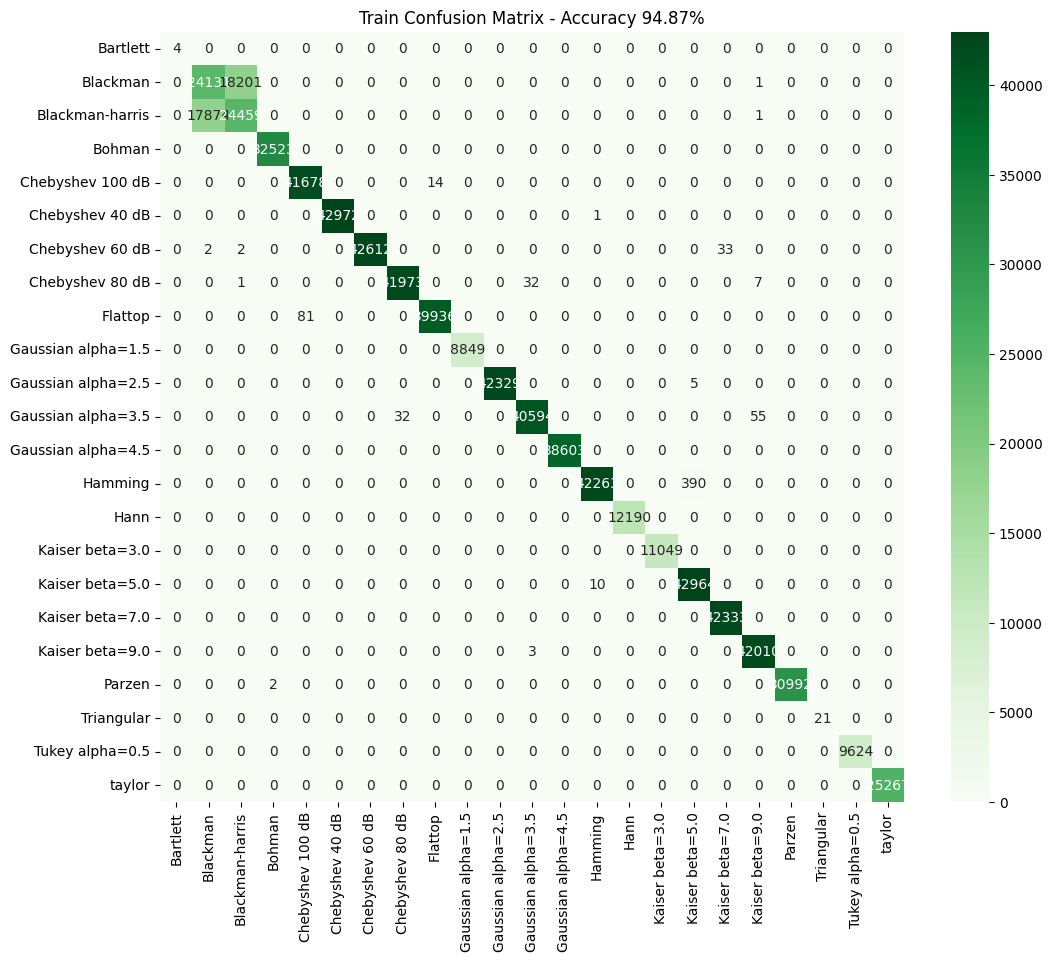


===== TEST SET METRICS =====
Accuracy : 90.077%
F1 Score : 0.901
Precision: 0.901
Recall   : 0.901

Classification Report:
                     precision    recall  f1-score   support

          Bartlett      0.500     1.000     0.667         1
          Blackman      0.202     0.202     0.202     10584
   Blackman-harris      0.206     0.207     0.206     10583
            Bohman      0.997     0.998     0.997      8131
  Chebyshev 100 dB      0.986     0.993     0.990     10423
   Chebyshev 40 dB      0.999     0.993     0.996     10744
   Chebyshev 60 dB      0.999     0.992     0.995     10662
   Chebyshev 80 dB      0.994     0.995     0.995     10503
           Flattop      0.992     0.985     0.989     10004
Gaussian alpha=1.5      1.000     1.000     1.000      2212
Gaussian alpha=2.5      0.998     0.999     0.998     10583
Gaussian alpha=3.5      0.993     0.986     0.990     10170
Gaussian alpha=4.5      1.000     1.000     1.000      9651
           Hamming      0.992     

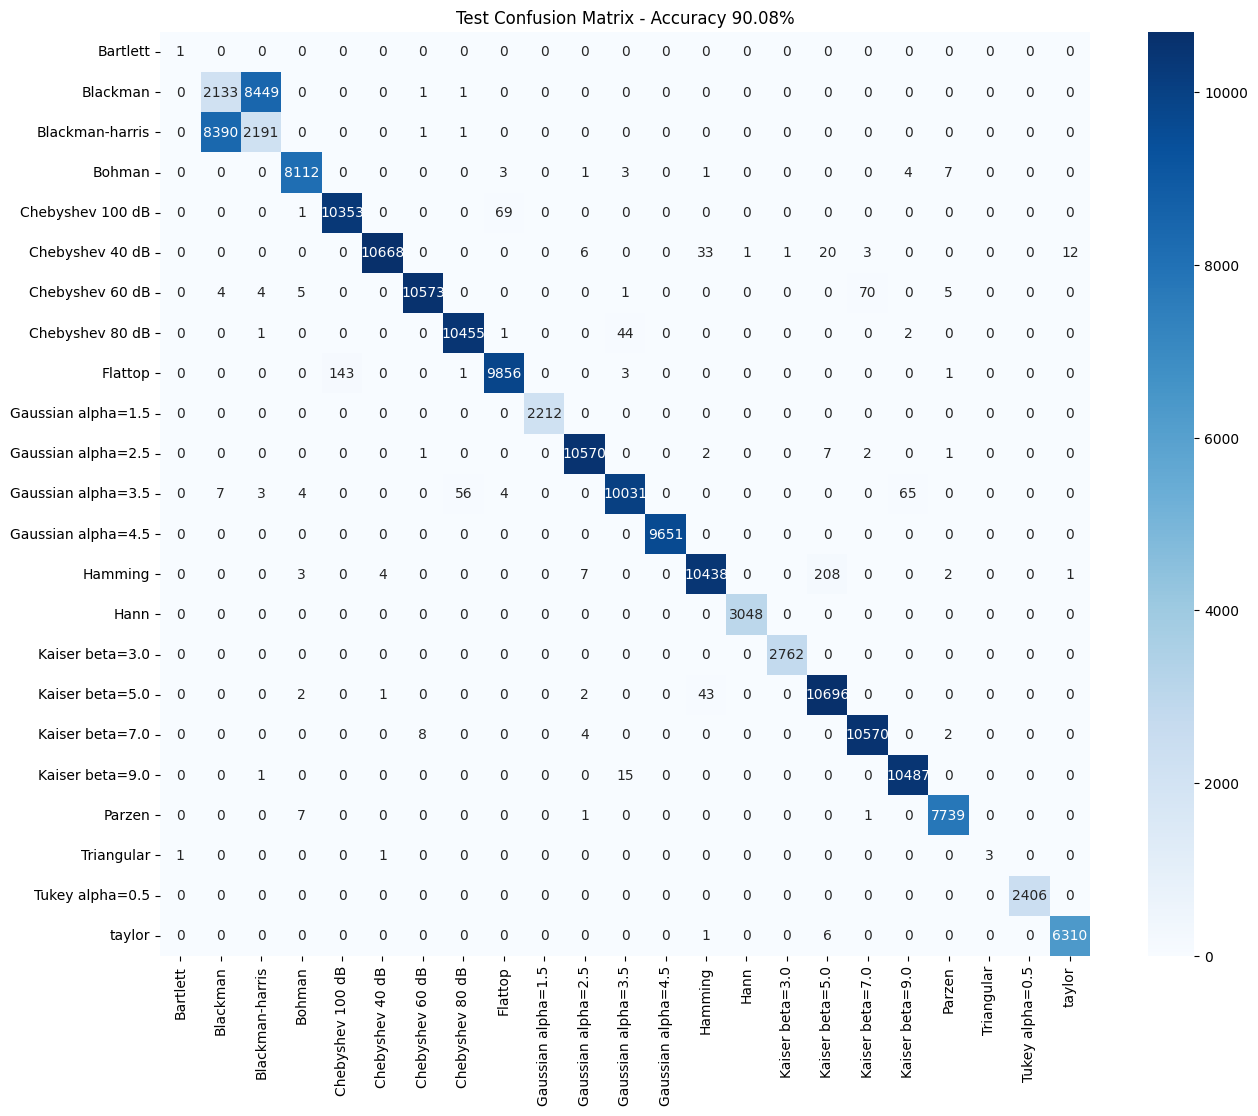

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report, confusion_matrix
from sklearn.impute import SimpleImputer
import lightgbm as lgb
from lightgbm import LGBMClassifier, LGBMRegressor
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# ===================================
# 1. DATA LOAD & CLEANING
# ===================================
df1 = pd.read_csv("/content/10_to_10090.csv")
df2 = pd.read_csv("/content/11000 to 15000.csv")
df = pd.concat([df1, df2], ignore_index=True)

df.rename(columns={
    "cutoff": "Cutoff_Hz",
    "sampling frequency": "Sampling_Freq_Hz",
    "filter length": "Filter_Length",
    "window": "Window",
    "passband ripples": "Passband_Ripple_inverted_dB",
    "stop band attenuation": "Stopband_Attenuation_inverted_dB",
    "transition band width": "Transition_BW_Hz",
    "snr": "SNR"
}, inplace=True)

df = df.dropna(subset=['Window', 'Cutoff_Hz', 'Sampling_Freq_Hz', 'Filter_Length', 'SNR'])
df = df[df["Stopband_Attenuation_inverted_dB"] >= 45].reset_index(drop=True)

# ===================================
# 2. FEATURE ENGINEERING
# ===================================
df["Cutoff_norm"] = df["Cutoff_Hz"] / df["Sampling_Freq_Hz"]
df["Transition_norm"] = df["Transition_BW_Hz"] / df["Sampling_Freq_Hz"]
df["Stopband_to_Passband"] = df["Stopband_Attenuation_inverted_dB"] / (df["Passband_Ripple_inverted_dB"] + 1e-6)
df["Ripple_atten_ratio"] = df["Passband_Ripple_inverted_dB"] / (df["Stopband_Attenuation_inverted_dB"] + 1e-6)
df["Log_ripple"] = np.log1p(df["Passband_Ripple_inverted_dB"])
df["Log_atten"] = np.log1p(df["Stopband_Attenuation_inverted_dB"])
df["Cutoff_to_Trans"] = df["Cutoff_Hz"] / (df["Transition_BW_Hz"] + 1)
df["Ripple_x_Cutoff_norm"] = df["Passband_Ripple_inverted_dB"] * df["Cutoff_norm"]
df["Atten_x_Trans_norm"] = df["Stopband_Attenuation_inverted_dB"] * df["Transition_norm"]

selected_features = [
    'Cutoff_norm',
    'Transition_norm',
    'Passband_Ripple_inverted_dB',
    'Stopband_Attenuation_inverted_dB',
    'Stopband_to_Passband',
    'Ripple_atten_ratio',
    'Log_ripple',
    'Cutoff_to_Trans',
    'Ripple_x_Cutoff_norm',
    'Atten_x_Trans_norm'
]

X = df[selected_features]
y = df["Window"]

# Imputation & Encoding
imputer = SimpleImputer(strategy='median')
X = pd.DataFrame(imputer.fit_transform(X), columns=selected_features)

le = LabelEncoder()
y_encoded = le.fit_transform(y)

# ===================================
# 3. TRAIN TEST SPLIT
# ===================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# ===================================
# 4. CLASSIFIER MODEL
# ===================================
lgb_model = LGBMClassifier(
    n_estimators=1800,
    learning_rate=0.02,
    max_depth=12,
    num_leaves=256,
    min_child_samples=20,
    subsample=0.85,
    colsample_bytree=0.7,
    reg_alpha=0.1,
    reg_lambda=0.3,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced',
    verbosity=-1
)

lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(150, verbose=100)]
)

# ===================================
# 5. REGRESSION MODEL
# ===================================
yL = df["Filter_Length"]

Xr_train, Xr_test, yL_train, yL_test = train_test_split(
    X, yL, test_size=0.2, random_state=42
)

lgb_reg = LGBMRegressor(
    n_estimators=2000,
    learning_rate=0.02,
    max_depth=12,
    num_leaves=256,
    subsample=0.85,
    colsample_bytree=0.7,
    reg_alpha=0.1,
    reg_lambda=0.3,
    random_state=42,
    n_jobs=-1
)

lgb_reg.fit(
    Xr_train, yL_train,
    eval_set=[(Xr_test, yL_test)],
    callbacks=[lgb.early_stopping(150)]
)

yL_pred = lgb_reg.predict(Xr_test)
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(yL_test, yL_pred)
print(f"\nFilter Length Regression MAE: {mae:.3f}")

# ============================================
# 6. DEPLOYMENT FUNCTION
# ============================================
def predict_window_and_length(
    cutoff_hz,
    sampling_freq_hz,
    transition_bw_hz,
    passband_ripple_db,
    stopband_atten_db
):
    feat = {
        "Cutoff_norm": cutoff_hz / sampling_freq_hz,
        "Transition_norm": transition_bw_hz / sampling_freq_hz,
        "Passband_Ripple_inverted_dB": passband_ripple_db,
        "Stopband_Attenuation_inverted_dB": stopband_atten_db,
        "Stopband_to_Passband": stopband_atten_db / (passband_ripple_db + 1e-6),
        "Ripple_atten_ratio": passband_ripple_db / (stopband_atten_db + 1e-6),
        "Log_ripple": np.log1p(passband_ripple_db),
        "Cutoff_to_Trans": cutoff_hz / (transition_bw_hz + 1),
        "Ripple_x_Cutoff_norm": passband_ripple_db * (cutoff_hz / sampling_freq_hz),
        "Atten_x_Trans_norm": stopband_atten_db * (transition_bw_hz / sampling_freq_hz)
    }

    input_df = pd.DataFrame([[feat[f] for f in selected_features]], columns=selected_features)
    input_df = pd.DataFrame(imputer.transform(input_df), columns=selected_features)

    pred_class = lgb_model.predict(input_df)[0]
    pred_window = le.inverse_transform([pred_class])[0]

    pred_length = lgb_reg.predict(input_df)[0]

    print("\n====================================")
    print("FINAL PREDICTION")
    print("====================================")
    print(f"Window Type   : {pred_window}")
    print(f"Filter Length : {int(round(pred_length))}")
    print("====================================")

    return pred_window, int(round(pred_length))

# ============================================
# 7. TRAINING & TEST METRICS & PLOTS
# ============================================
def plot_metrics(y_true, y_pred, dataset="Train"):
    y_pred = y_pred.ravel()
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='weighted')
    precision = precision_score(y_true, y_pred, average='weighted')

    recall = recall_score(y_true, y_pred, average='weighted')

    print(f"\n===== {dataset.upper()} SET METRICS =====")
    print(f"Accuracy : {acc*100:.3f}%")
    print(f"F1 Score : {f1:.3f}")
    print(f"Precision: {precision:.3f}")
    print(f"Recall   : {recall:.3f}")
    print("\nClassification Report:\n", classification_report(
        y_true, y_pred, target_names=le.classes_, digits=3
    ))

    cm = confusion_matrix(y_true, y_pred, labels=np.arange(len(le.classes_)))
    plt.figure(figsize=(12,10) if dataset=="Train" else (15,12))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens' if dataset=="Train" else "Blues",
                xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f"{dataset} Confusion Matrix - Accuracy {acc*100:.2f}%")
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.show()

# Train Metrics
y_train_pred = lgb_model.predict(X_train)
plot_metrics(y_train, y_train_pred, dataset="Train")

# Test Metrics
y_test_pred = lgb_model.predict(X_test)
plot_metrics(y_test, y_test_pred, dataset="Test")


In [3]:
# ============================================
# 7. REAL-TIME USER DESIGN INPUT
# ============================================

cutoff_inp      = float(input("Enter Cutoff Frequency (Hz): "))
fs_inp          = float(input("Enter Sampling Frequency (Hz): "))
transition_inp = float(input("Enter Transition Bandwidth (Hz): "))
passband_inp   = float(input("Enter Passband Ripple (dB): "))
stopband_inp   = float(input("Enter Stopband Attenuation (dB): "))

win, L = predict_window_and_length(
    cutoff_inp,
    fs_inp,
    transition_inp,
    passband_inp,
    stopband_inp
)

print("\nSUMMARY:")
print("Window Type  →", win)
print("Filter Length →", L)


Enter Cutoff Frequency (Hz): 40
Enter Sampling Frequency (Hz): 250
Enter Transition Bandwidth (Hz): 10
Enter Passband Ripple (dB): 0.1
Enter Stopband Attenuation (dB): 90


NameError: name 'predict_window_and_length' is not defined